In [3]:
from sklearn.model_selection import train_test_split


In [3]:
from mne.datasets.sleep_physionet import fetch_data

data = fetch_data(subjects=[0], recording=[1])
data


ImportError: cannot import name 'fetch_data' from 'mne.datasets.sleep_physionet' (/usr/local/python/3.12.1/lib/python3.12/site-packages/mne/datasets/sleep_physionet/__init__.py)

In [2]:
!pip install --upgrade mne


In [1]:
!pip install mne==1.6.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 11.5 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: mne
    Found existing installation: mne 1.10.2
    Uninstalling mne-1.10.2:
      Successfully uninstalled mne-1.10.2


In [1]:
import mne
mne.__version__


'1.6.0'

In [4]:
from mne.datasets.sleep_physionet import age

# Download Subject 0, Recording 1
data = age.fetch_data(subjects=[0], recording=[1])
data


Using default location ~/mne_data for PHYSIONET_SLEEP...
Creating ~/mne_data


100%|█████████████████████████████████████| 48.3M/48.3M [00:00<00:00, 62.5GB/s]
100%|█████████████████████████████████████| 4.62k/4.62k [00:00<00:00, 2.80MB/s]

Download complete in 01m05s (46.1 MB)


[['/home/codespace/mne_data/physionet-sleep-data/SC4001E0-PSG.edf',
  '/home/codespace/mne_data/physionet-sleep-data/SC4001EC-Hypnogram.edf']]

In [5]:
import mne

edf_path = data[0][0]   # polysomnogram EDF
raw = mne.io.read_raw_edf(edf_path, preload=True)
raw


Extracting EDF parameters from /home/codespace/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


Measurement date,"April 24, 1989 16:13:00 GMT"
Experimenter,Unknown
Participant,X
Digitized points,Not available
Good channels,7 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,100.00 Hz
Highpass,0.50 Hz
Lowpass,100.00 Hz


In [2]:
import mne

# If you already have 'data' from age.fetch_data earlier:
from mne.datasets.sleep_physionet import age
data = age.fetch_data(subjects=[0], recording=[1])

edf_path = data[0][0]  # first EDF file = PSG
raw = mne.io.read_raw_edf(edf_path, preload=True)
raw


Using default location ~/mne_data for PHYSIONET_SLEEP...
Extracting EDF parameters from /home/codespace/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


Measurement date,"April 24, 1989 16:13:00 GMT"
Experimenter,Unknown
Participant,X
Digitized points,Not available
Good channels,7 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,100.00 Hz
Highpass,0.50 Hz
Lowpass,100.00 Hz


Using matplotlib as 2D backend.


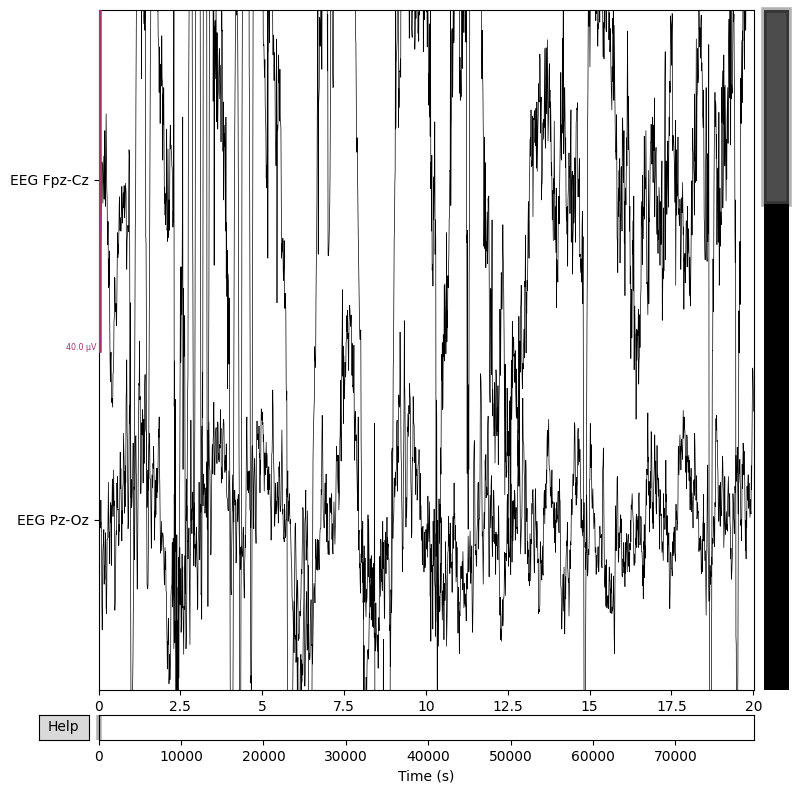

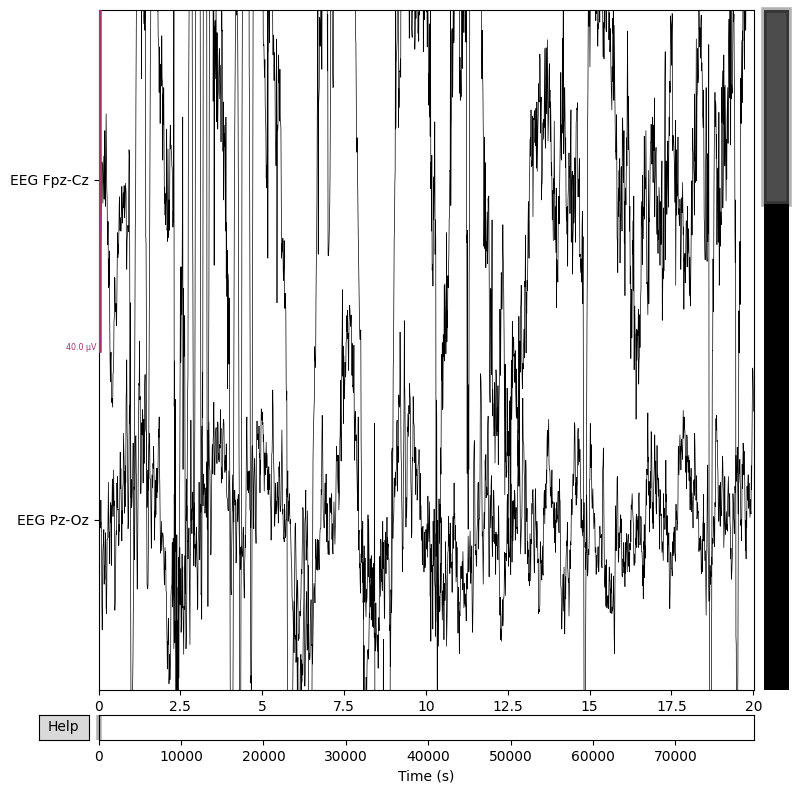

In [3]:
raw.plot(duration=20, n_channels=2)


In [1]:
from mne.datasets.sleep_physionet import age
import mne

# Load data again
data = age.fetch_data(subjects=[0], recording=[1])
edf_path = data[0][0]

raw = mne.io.read_raw_edf(edf_path, preload=True)
raw


Using default location ~/mne_data for PHYSIONET_SLEEP...
Extracting EDF parameters from /home/codespace/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


Measurement date,"April 24, 1989 16:13:00 GMT"
Experimenter,Unknown
Participant,X
Digitized points,Not available
Good channels,7 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,100.00 Hz
Highpass,0.50 Hz
Lowpass,100.00 Hz


In [2]:
# Apply standard sleep EEG band-pass filter
raw_filtered = raw.copy().filter(l_freq=0.5, h_freq=30)
raw_filtered


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (6.610 s)



[Parallel(n_jobs=1)]: Done   7 out of   7 | elapsed:    3.2s finished


Measurement date,"April 24, 1989 16:13:00 GMT"
Experimenter,Unknown
Participant,X
Digitized points,Not available
Good channels,7 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,100.00 Hz
Highpass,0.50 Hz
Lowpass,30.00 Hz


In [4]:
# Epoch length = 30 seconds
epoch_length = 30   # seconds
sfreq = raw_filtered.info['sfreq']  # sampling rate

samples_per_epoch = int(epoch_length * sfreq)
samples_per_epoch


3000

In [5]:
# Load hypnogram file
hypno_path = data[0][1]  # second file is the hypnogram

hypno = mne.read_annotations(hypno_path)
hypno


<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>

In [11]:
import numpy as np

# Map textual sleep stage labels to integers
stage_map = {
    "Sleep stage W": 5,   # Wake
    "Sleep stage 1": 1,   # N1
    "Sleep stage 2": 2,   # N2
    "Sleep stage 3": 3,   # N3
    "Sleep stage 4": 3,   # (older scoring; we merge into N3)
    "Sleep stage R": 4,   # REM
    "Sleep stage ?": 0,   # unknown / artefact
    "Movement time": 0,   # treat as "other"
}

epoch_labels = []

n_epochs = int(raw_filtered.n_times // samples_per_epoch)

for i in range(n_epochs):
    # epoch boundaries in *seconds*
    start_t = i * epoch_length
    mid_t = start_t + epoch_length / 2.0  # middle of the epoch

    label_code = 0  # default = "unknown/other"

    # find which annotation covers the epoch midpoint
    for onset, duration, desc in zip(hypno.onset, hypno.duration, hypno.description):
        if onset <= mid_t < onset + duration:
            label_code = stage_map.get(desc, 0)
            break

    epoch_labels.append(label_code)

len(epoch_labels), epoch_labels[:20]


(2650, [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

In [12]:
epochs = mne.make_fixed_length_epochs(
    raw_filtered,
    duration=epoch_length,
    preload=True
)

len(epochs), len(epoch_labels)


Not setting metadata
2650 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2650 events and 3000 original time points ...
0 bad epochs dropped


(2650, 2650)

In [13]:
min_len = min(len(epochs), len(epoch_labels))
epochs = epochs[:min_len]
epoch_labels = np.array(epoch_labels[:min_len])

len(epochs), len(epoch_labels)


(2650, 2650)

In [14]:
from scipy.signal import welch

def bandpower(epoch, sf, band):
    freqs, psd = welch(epoch, sf)
    idx = (freqs >= band[0]) & (freqs <= band[1])
    return np.trapz(psd[idx], freqs[idx])

sf = raw_filtered.info["sfreq"]

features = []
for e in epochs.get_data():   # shape: (n_channels, n_times)
    sig = e[0]  # use first EEG channel only for now
    epoch_features = [
        bandpower(sig, sf, (0.5, 4)),    # delta
        bandpower(sig, sf, (4, 8)),      # theta
        bandpower(sig, sf, (8, 12)),     # alpha
        bandpower(sig, sf, (12, 30)),    # beta
        np.sqrt(np.mean(sig ** 2)),      # RMS amplitude
    ]
    features.append(epoch_features)

features = np.array(features)
features.shape, epoch_labels.shape


/tmp/ipykernel_2059/1967776789.py:11: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  for e in epochs.get_data():   # shape: (n_channels, n_times)
/tmp/ipykernel_2059/1967776789.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])


((2650, 5), (2650,))

In [15]:
import pandas as pd

df = pd.DataFrame(features, columns=['delta', 'theta', 'alpha', 'beta', 'rms'])
df['label'] = epoch_labels

df.to_csv('../results/sleep_features.csv', index=False)
df.head()


,delta,theta,alpha,beta,rms,label
0,4.477272e-10,7.268459e-11,7.219032e-12,1.108876e-11,0.000034,5
1,3.008549e-10,3.779951e-11,1.027551e-11,3.190424e-11,0.000024,5
2,3.510074e-10,1.946380e-11,1.152880e-11,1.772940e-11,0.000029,5
3,1.709253e-10,1.650516e-11,1.094063e-11,7.913652e-12,0.000016,5
4,1.624115e-10,3.251658e-11,9.248746e-12,6.672604e-12,0.000017,5


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../results/sleep_features.csv')

X = df[['delta', 'theta', 'alpha', 'beta', 'rms']].values
y = df['label'].values

X.shape, y.shape


((2650, 5), (2650,))

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
acc


0.8905660377358491

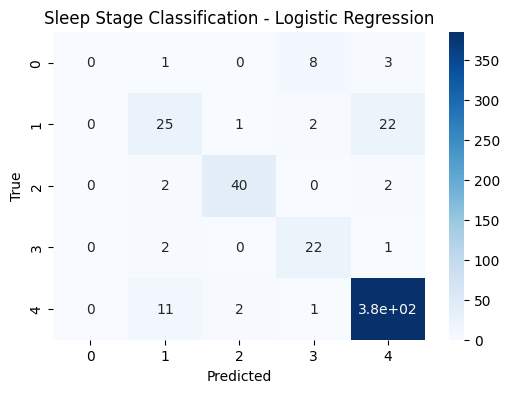

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Sleep Stage Classification - Logistic Regression")
plt.show()


In [11]:
with open('../results/model_results.txt', 'w') as f:
    f.write(f"Accuracy: {acc}\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm))
